In [1]:
import pandas as pd

reports_df = pd.read_csv("preprocessed_content.csv")
risk_df = pd.read_csv("SP 500 ESG Risk Ratings.csv")

print("REPORT DATASET")
print(reports_df.shape)
print(reports_df.columns)

print("\n")

print("RISK DATASET")
print(risk_df.shape)
print(risk_df.columns)

REPORT DATASET
(866, 10)
Index(['Unnamed: 0', 'filename', 'ticker', 'year', 'preprocessed_content',
       'ner_entities', 'e_score', 's_score', 'g_score', 'total_score'],
      dtype='object')


RISK DATASET
(503, 15)
Index(['Symbol', 'Name', 'Address', 'Sector', 'Industry',
       'Full Time Employees', 'Description', 'Total ESG Risk score',
       'Environment Risk Score', 'Governance Risk Score', 'Social Risk Score',
       'Controversy Level', 'Controversy Score', 'ESG Risk Percentile',
       'ESG Risk Level'],
      dtype='object')


In [2]:
reports_tickers = set(reports_df['ticker'].astype(str).str.upper())

risk_tickers = set(risk_df['Symbol'].astype(str).str.upper())

common = reports_tickers.intersection(risk_tickers)

print("Reports tickers:", len(reports_tickers))
print("Risk tickers:", len(risk_tickers))
print("Common tickers:", len(common))

print("\nSample common tickers:")
print(list(common)[:20])

Reports tickers: 263
Risk tickers: 503
Common tickers: 262

Sample common tickers:
['AVY', 'GRMN', 'PKG', 'ZTS', 'PSX', 'DHI', 'ROK', 'INTU', 'DXCM', 'LRCX', 'SJM', 'QRVO', 'UHS', 'CHD', 'AMT', 'GPC', 'MDT', 'REGN', 'APA', 'FAST']


In [3]:
# Standardize ticker names

reports_df['ticker'] = reports_df['ticker'].astype(str).str.upper()
risk_df['Symbol'] = risk_df['Symbol'].astype(str).str.upper()

# Merge

merged_df = pd.merge(
    reports_df,
    risk_df,
    left_on='ticker',
    right_on='Symbol',
    how='inner'
)

print("Merged Shape:", merged_df.shape)

print("\nColumns:")
print(merged_df.columns.tolist())

Merged Shape: (862, 25)

Columns:
['Unnamed: 0', 'filename', 'ticker', 'year', 'preprocessed_content', 'ner_entities', 'e_score', 's_score', 'g_score', 'total_score', 'Symbol', 'Name', 'Address', 'Sector', 'Industry', 'Full Time Employees', 'Description', 'Total ESG Risk score', 'Environment Risk Score', 'Governance Risk Score', 'Social Risk Score', 'Controversy Level', 'Controversy Score', 'ESG Risk Percentile', 'ESG Risk Level']


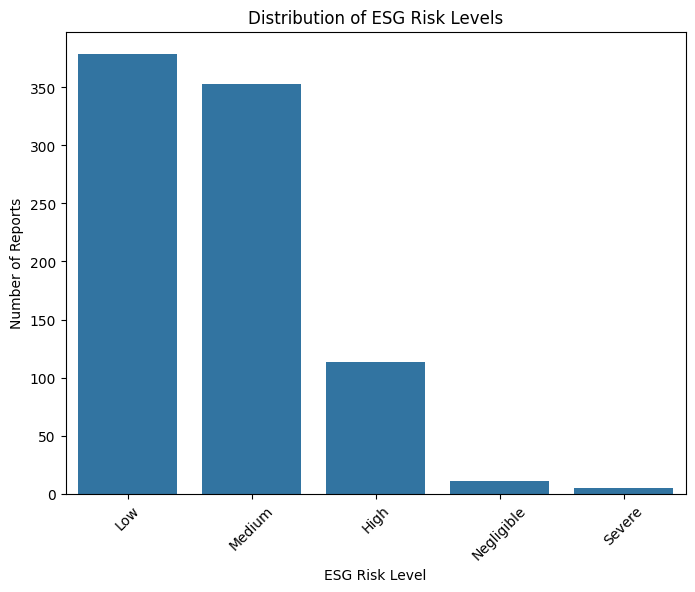

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.countplot(
    data=merged_df,
    x='ESG Risk Level',
    order=merged_df['ESG Risk Level'].value_counts().index
)

plt.title("Distribution of ESG Risk Levels")
plt.xlabel("ESG Risk Level")
plt.ylabel("Number of Reports")

plt.xticks(rotation=45)

plt.show()

In [5]:
print(merged_df[['ticker',
                 'year',
                 'total_score',
                 'Total ESG Risk score',
                 'ESG Risk Level']].head())

  ticker  year  total_score  Total ESG Risk score ESG Risk Level
0    BSX  2020        32.98                  23.1         Medium
1    BSX  2022        26.02                  23.1         Medium
2    EXR  2022        13.94                  15.2            Low
3    ADM  2019        36.36                  31.8           High
4    ADM  2020        34.78                  31.8           High


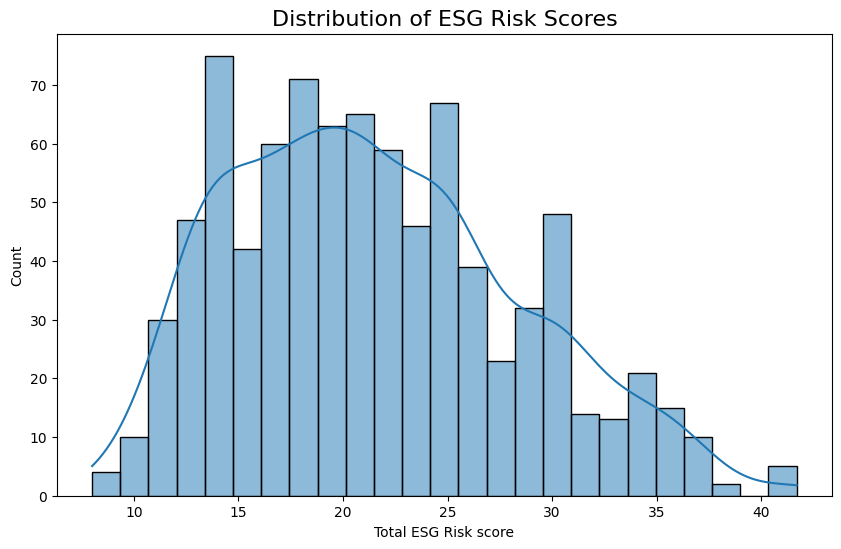

In [6]:
#EDA Figure 2: ESG Risk Score Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    merged_df['Total ESG Risk score'],
    bins=25,
    kde=True
)

plt.title(
    'Distribution of ESG Risk Scores',
    fontsize=16
)

plt.show()

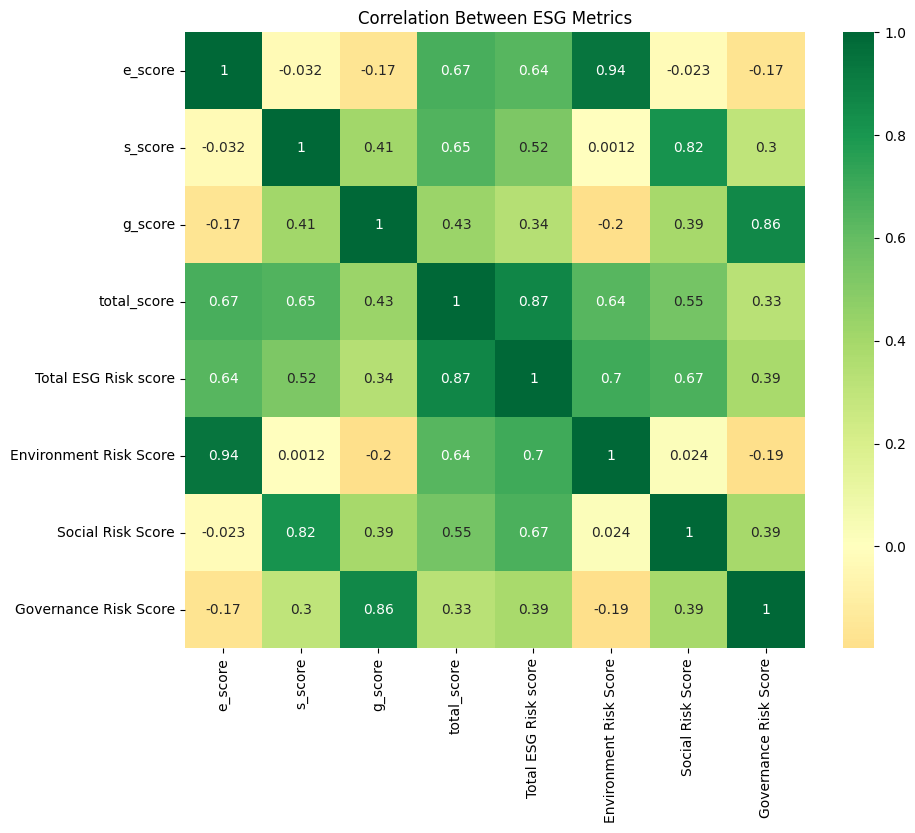

In [7]:
#EDA Figure 3: Correlation Heatmap

plt.figure(figsize=(10,8))

corr = merged_df[
[
'e_score',
's_score',
'g_score',
'total_score',
'Total ESG Risk score',
'Environment Risk Score',
'Social Risk Score',
'Governance Risk Score'
]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    center=0
)

plt.title(
    'Correlation Between ESG Metrics'
)

plt.show()

In [8]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [9]:
#Create Better Hedging Dictionary
hedging_words = [
    "may",
    "might",
    "could",
    "aim",
    "seek",
    "strive",
    "intend",
    "aspire",
    "hope",
    "plan",
    "target",
    "commit",
    "endeavor",
    "working",
    "working toward"
]

In [10]:
#Promotional Dictionary
promotional_words = [
    "leading",
    "best",
    "innovative",
    "world-class",
    "revolutionary",
    "outstanding",
    "excellent",
    "unique",
    "pioneer",
    "industry-leading",
    "leader",
    "leadership",
    "top",
    "premier",
    "exceptional"
]

In [11]:
def count_words(text, word_list):

    text = str(text).lower()

    words = text.split()

    return sum(words.count(word) for word in word_list)

In [12]:
merged_df["hedging_count"] = merged_df[
    "preprocessed_content"
].apply(
    lambda x: count_words(x, hedging_words)
)

merged_df["promotion_count"] = merged_df[
    "preprocessed_content"
].apply(
    lambda x: count_words(x, promotional_words)
)

In [13]:
def evidence_score(text):

    text = str(text)

    return len(re.findall(r'\d+', text))

    merged_df["evidence_score"] = merged_df[
    "preprocessed_content"
].apply(evidence_score)

In [15]:
print(merged_df.columns.tolist())

['Unnamed: 0', 'filename', 'ticker', 'year', 'preprocessed_content', 'ner_entities', 'e_score', 's_score', 'g_score', 'total_score', 'Symbol', 'Name', 'Address', 'Sector', 'Industry', 'Full Time Employees', 'Description', 'Total ESG Risk score', 'Environment Risk Score', 'Governance Risk Score', 'Social Risk Score', 'Controversy Level', 'Controversy Score', 'ESG Risk Percentile', 'ESG Risk Level', 'hedging_count', 'promotion_count']


In [16]:
print(merged_df["preprocessed_content"].sample(1).values[0][:1000])

report global company expand access wireless communication dedicate generate term value stockholder embrace responsibility deliver value tenant invest employee interact supplier support surround president ceo executive summary story corporate responsibility corporate governance risk management stakeholder engagement think leadership cybersecurity information technology define material topic ethic educating engage employee accountability track supplier guideline people listen employee development promote diversity inclusion health safety management environment overview energy usage clean energy solution energy consumption energy future land stewardship philanthropy technology infrastructure support community engagement future philanthropy performance financial performance innovation principle reporting gri content index tcfd sasb index continue execute stand deliver strategy corporate sustainability remain critical component operate philosophy mission commitment stakeholder cornerstone 

In [17]:
print(merged_df["preprocessed_content"].iloc[0][:1000])

style guide colour colour use imagecolour professional print pantone gold black single colour use blackreverse colour use black dark photo use reverse logo dark photo read photo gold foil cmyk crop photoof gold foil use normal logo light photo read sustainability content introduction manage director report highlight report story khoa sustainability strategy journey share blackstone vision responsible sustainable mining understand sustainability mean blackstone stakeholder share value material issue responsibility sustainability sustainable development goal future action activity health safety wellbee review develop safety understanding skill pandemic response dapte technology reduce frontline risk pandemic esponsible business good governance troduction board vernment engagement permit environment climate change create positive legacy community environment limate change een nickel integrate value chain renewable power pressure oxidation pox ossil fuel consortium calendar year emission a

In [18]:
merged_df["preprocessed_content"].str.contains(r"\d", regex=True).sum()

np.int64(0)

In [19]:
#Creating Environmental Count
environmental_words = [
    "sustainability",
    "sustainable",
    "environment",
    "environmental",
    "climate",
    "carbon",
    "emission",
    "renewable",
    "energy",
    "waste",
    "water",
    "green"
]

merged_df["environmental_count"] = merged_df[
    "preprocessed_content"
].apply(
    lambda x: count_words(x, environmental_words)
)

In [20]:
#Creating word count
merged_df["word_count"] = (
    merged_df["preprocessed_content"]
    .str.split()
    .str.len()
)

In [21]:
#verification
merged_df[
[
    "hedging_count",
    "promotion_count",
    "environmental_count",
    "word_count"
]
].describe()

,hedging_count,promotion_count,environmental_count,word_count
count,862.000000,862.000000,862.000000,862.000000
mean,80.316705,52.511601,408.467517,11946.010441
std,76.763181,36.617516,325.733370,8047.218033
min,0.000000,0.000000,0.000000,21.000000
25%,35.250000,26.000000,167.000000,6357.000000
50%,64.000000,46.000000,328.000000,10059.000000
75%,100.000000,71.000000,555.000000,15494.250000
max,721.000000,226.000000,2334.000000,53117.000000


In [22]:
##RQ1
#How do linguistic characteristics vary across ESG Risk Levels?

In [23]:
rq1_df = merged_df.groupby(
    "ESG Risk Level"
)[
[
    "hedging_count",
    "promotion_count",
    "environmental_count"
]
].mean().reset_index()

print(rq1_df)

  ESG Risk Level  hedging_count  promotion_count  environmental_count
0           High      93.637168        51.699115           482.831858
1            Low      76.736148        49.894459           397.213720
2         Medium      79.507082        55.232295           395.331445
3     Negligible      87.545455        63.454545           436.000000
4         Severe      71.200000        33.600000           443.400000


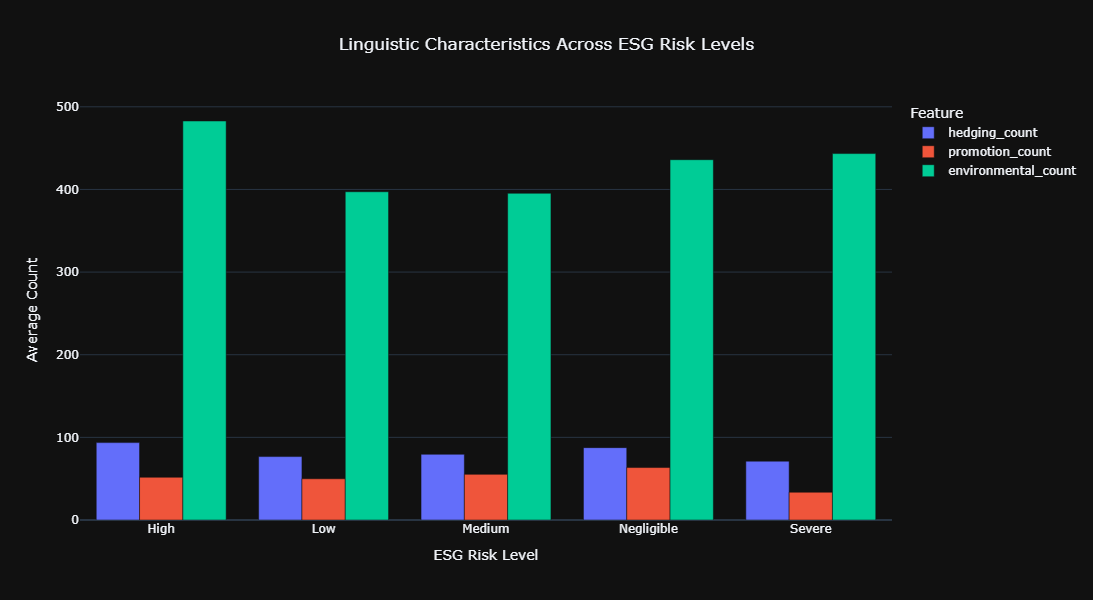

In [24]:
import plotly.express as px

rq1_melted = rq1_df.melt(
    id_vars="ESG Risk Level",
    var_name="Feature",
    value_name="Average Count"
)

fig = px.bar(
    rq1_melted,
    x="ESG Risk Level",
    y="Average Count",
    color="Feature",
    barmode="group",
    title="Linguistic Characteristics Across ESG Risk Levels",
    template="plotly_dark"
)

fig.update_layout(
    width=1000,
    height=600,
    title_x=0.5
)

fig.show()

In [25]:
fig.write_html("RQ1_Linguistic_Features.html")

In [26]:
fig.write_image("RQ1_Linguistic_Features.png")

In [27]:
fig.write_image("RQ1_Linguistic_Features.pdf")

In [28]:
print(rq1_df)

  ESG Risk Level  hedging_count  promotion_count  environmental_count
0           High      93.637168        51.699115           482.831858
1            Low      76.736148        49.894459           397.213720
2         Medium      79.507082        55.232295           395.331445
3     Negligible      87.545455        63.454545           436.000000
4         Severe      71.200000        33.600000           443.400000


In [29]:
##RQ2
#Is sustainability language intensity associated with ESG Risk Scores?

In [30]:
merged_df["environmental_density"] = (
    merged_df["environmental_count"] /
    merged_df["word_count"]
) * 1000

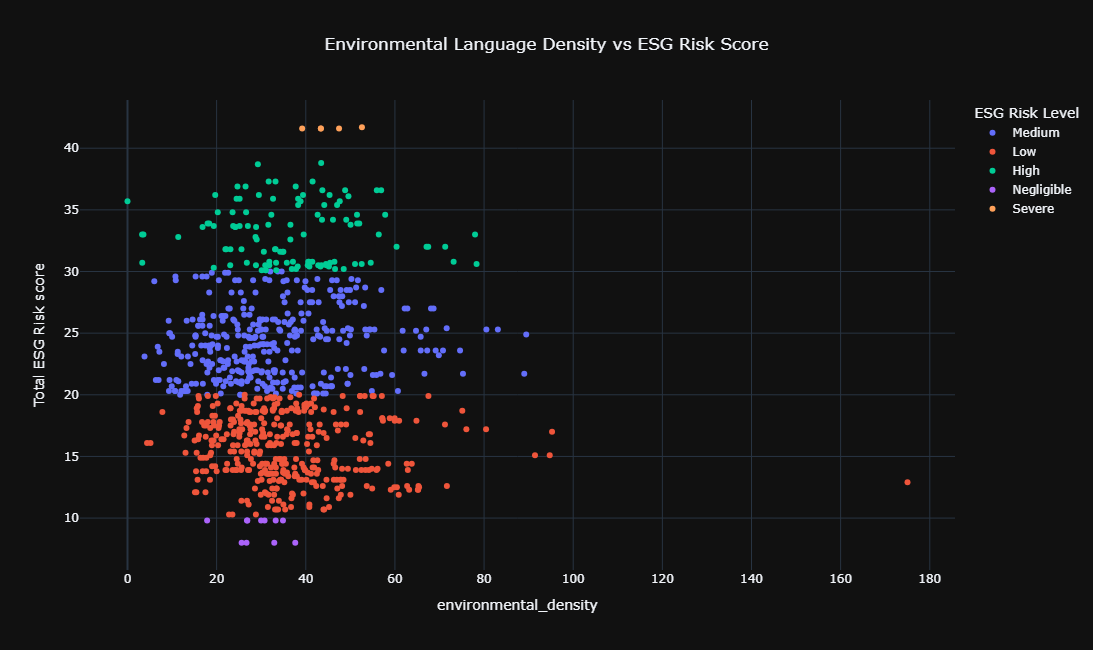

In [31]:
import plotly.express as px

fig = px.scatter(
    merged_df,
    x="environmental_density",
    y="Total ESG Risk score",
    color="ESG Risk Level",
    hover_data=[
        "ticker",
        "year",
        "Sector"
    ],
    title="Environmental Language Density vs ESG Risk Score",
    template="plotly_dark"
)

fig.update_layout(
    width=1000,
    height=650,
    title_x=0.5
)

fig.show()

In [33]:
fig.write_image("RQ2_Environmental_Density_vs_ESG_Risk.pdf")

In [34]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(
    merged_df["environmental_density"],
    merged_df["Total ESG Risk score"]
)

print("Spearman Correlation:", corr)
print("P-value:", p_value)

Spearman Correlation: nan
P-value: nan


In [35]:
print(
    merged_df[
        ["environmental_density",
         "Total ESG Risk score"]
    ].isnull().sum()
)

environmental_density    0
Total ESG Risk score     1
dtype: int64


In [36]:
print(
    merged_df["environmental_density"]
    .describe()
)

count    862.000000
mean      34.619618
std       15.593704
min        0.000000
25%       24.714113
50%       32.570438
75%       42.771435
max      175.000000
Name: environmental_density, dtype: float64


In [37]:
import numpy as np

print(
    np.isinf(
        merged_df["environmental_density"]
    ).sum()
)

0


In [38]:
corr_df = merged_df[
[
    "environmental_density",
    "Total ESG Risk score"
]
].replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

In [39]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(
    corr_df["environmental_density"],
    corr_df["Total ESG Risk score"]
)

print("Spearman Correlation:", corr)
print("P-value:", p_value)

Spearman Correlation: -0.005203731131218657
P-value: 0.8788152602347793


In [40]:
merged_df["environmental_density"].describe()

merged_df["environmental_density"].nunique()

merged_df[
["environmental_density",
 "Total ESG Risk score"]
].isnull().sum()

environmental_density    0
Total ESG Risk score     1
dtype: int64

In [41]:
##RQ3 
#What sustainability topics dominate reports of companies with different ESG Risk Levels?

In [43]:
pip install bertopic

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.9 MB ? eta -:--:--
   ---------------- ----------------------- 0.8/1.9 MB 2.1 MB/s eta 0:00:01
   -------------------------- ------------- 1.3/1.9 MB 2.6 MB/s eta 0:00:01
   -------------------------------- ------- 1.6/1.9 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 1.9/1.9 MB 2.2 MB/s eta 0:00:00

   ---------- ----------------------------- 1/4 [hdbscan]
   -------------------- ------------------- 2/4 [umap-learn]
   ------------------------------ --------- 3/4 [bertopic]
   ---------------------------------------- 4/4 [bertopic]

Note: you may need to restart the kernel to use updated packages.


In [44]:
pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [45]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [46]:
pip install hdbscan

Note: you may need to restart the kernel to use updated packages.


In [47]:
merged_df["word_count"].describe()

count      862.000000
mean     11946.010441
std       8047.218033
min         21.000000
25%       6357.000000
50%      10059.000000
75%      15494.250000
max      53117.000000
Name: word_count, dtype: float64

In [48]:
merged_df.to_csv(
    "merged_feature_engineered.csv",
    index=False
)

In [49]:
sample_df = merged_df.sample(
    n=100,
    random_state=42
)

In [51]:
sample_df["short_text"] = sample_df[
    "preprocessed_content"
].apply(
    lambda x: " ".join(
        str(x).split()[:2000]
    )
)

In [52]:
documents = sample_df[
    "short_text"
].tolist()

print(len(documents))

100


In [53]:
from bertopic import BERTopic

topic_model = BERTopic(
    verbose=True
)

topics, probs = topic_model.fit_transform(
    documents
)

C:\Users\HP\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-07 14:04:10,557 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 4/4 [00:04<00:00,  1.18s/it]
2026-06-07 14:04:19,301 - BERTopic - Embedding - Completed ✓
2026-06-07 14:04:19,301 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-07 14:04:32,029 - BERTopic - Dimensionality - Completed ✓
2026-06-07 14:04:32,029 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-07 14:04:32,068 - BERTopic - Cluster - Completed ✓
2026-06-07 14:04:32,088 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-07 14:04:32,291 - BERTopic - Representation - Completed ✓


In [54]:
topic_info = topic_model.get_topic_info()

In [55]:
print(topic_info.head(15))

   Topic  Count                                     Name  \
0     -1     36    -1_business_employee_company_customer   
1      0     36  0_sustainability_energy_report_business   
2      1     14           1_health_care_patient_employee   
3      2     14    2_employee_business_program_corporate   

                                      Representation  \
0  [business, employee, company, customer, esg, i...   
1  [sustainability, energy, report, business, pro...   
2  [health, care, patient, employee, company, sus...   
3  [employee, business, program, corporate, compa...   

                                 Representative_Docs  
0  [report reportabout report report detail esg p...  
1  [advance global impact report cover cover imag...  
2  [health humanity report content pandemic commu...  
3  [corporate social responsibility report mornea...  


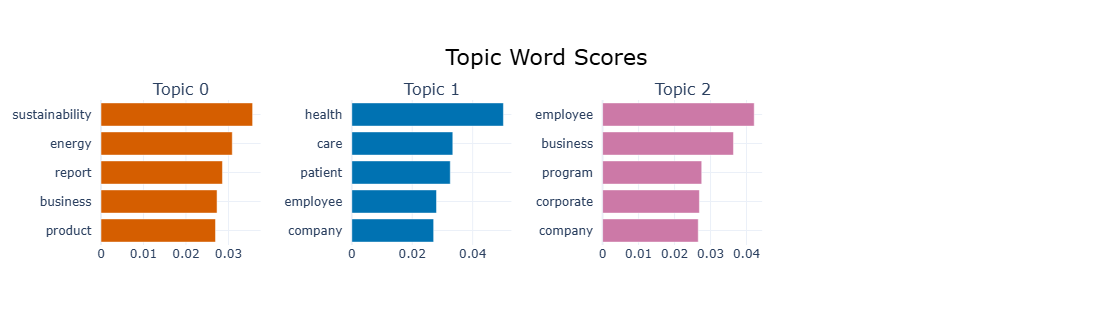

In [56]:
fig = topic_model.visualize_barchart(
    top_n_topics=10
)

fig.show()

In [57]:
fig.write_image("RQ3_Topic_Barchart.pdf")

In [58]:
for topic in topic_info.Topic.unique():

    if topic != -1:

        print(f"\nTopic {topic}")

        print(
            topic_model.get_topic(topic)
        )


Topic 0
[('sustainability', np.float64(0.03568165264106108)), ('energy', np.float64(0.030891475800993353)), ('report', np.float64(0.02858102628612359)), ('business', np.float64(0.02731148152037041)), ('product', np.float64(0.02694816744803739)), ('employee', np.float64(0.026062709713823785)), ('community', np.float64(0.02554704483910007)), ('emission', np.float64(0.025346353536625427)), ('customer', np.float64(0.023614900778300852)), ('company', np.float64(0.02296717393361814))]

Topic 1
[('health', np.float64(0.0501819841961426)), ('care', np.float64(0.03342910228613524)), ('patient', np.float64(0.03259392592598248)), ('employee', np.float64(0.028034034324466394)), ('company', np.float64(0.02709106829553058)), ('sustainability', np.float64(0.025413699342145633)), ('program', np.float64(0.024365203865634632)), ('help', np.float64(0.023235849190981435)), ('global', np.float64(0.023152493552346998)), ('support', np.float64(0.022355705806750406))]

Topic 2
[('employee', np.float64(0.0421

In [59]:
##RQ4 
#Can an AI-based Greenwashing Risk Index be developed using linguistic characteristics and ESG risk metrics?

In [60]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features = [
    "hedging_count",
    "promotion_count",
    "environmental_density",
    "Total ESG Risk score"
]

merged_df[features] = scaler.fit_transform(
    merged_df[features]
)

In [61]:
merged_df["greenwashing_index"] = (
      0.30 * merged_df["hedging_count"]
    + 0.20 * merged_df["promotion_count"]
    + 0.30 * merged_df["Total ESG Risk score"]
    + 0.20 * merged_df["environmental_density"]
)

In [67]:
import plotly.express as px

fig = px.histogram(
    merged_df_scaled,
    x="greenwashing_index",
    nbins=30,
    title="Distribution of Greenwashing Risk Index",
    template="plotly_dark",
    marginal="box"
)

fig.update_layout(
    width=1000,
    height=600,
    title_x=0.5
)

fig.show()

NameError: name 'merged_df_scaled' is not defined

In [68]:
%whos

Variable               Type            Data/Info
------------------------------------------------
BERTopic               type            <class 'bertopic._bertopic.BERTopic'>
MinMaxScaler           type            <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
common                 set             {'AVY', 'GRMN', 'PKG', 'Z<...>K', 'AMZN', 'STT', 'SWK'}
corr                   float64         -0.005203731131218657
corr_df                DataFrame       Shape: (861, 2)
count_words            function        <function count_words at 0x00000242035A8AE0>
dataframe_columns      function        <function dataframe_colum<...>ns at 0x000002424211F420>
dataframe_hash         function        <function dataframe_hash at 0x000002420E5AB100>
documents              list            n=100
dtypes_str             function        <function dtypes_str at 0x00000242035A8860>
environmental_words    list            n=12
evidence_score         function        <function evidence_score at 0x00000242035A

In [69]:
from sklearn.preprocessing import MinMaxScaler

# Create a copy
merged_df_scaled = merged_df.copy()

scaler = MinMaxScaler()

features = [
    "hedging_count",
    "promotion_count",
    "environmental_density",
    "Total ESG Risk score"
]

merged_df_scaled[features] = scaler.fit_transform(
    merged_df_scaled[features]
)

merged_df_scaled["greenwashing_index"] = (
      0.30 * merged_df_scaled["hedging_count"]
    + 0.20 * merged_df_scaled["promotion_count"]
    + 0.30 * merged_df_scaled["Total ESG Risk score"]
    + 0.20 * merged_df_scaled["environmental_density"]
)

print(
    merged_df_scaled[
        ["greenwashing_index"]
    ].describe()
)

       greenwashing_index
count          861.000000
mean             0.239627
std              0.086073
min              0.047886
25%              0.176023
50%              0.227512
75%              0.290529
max              0.623561


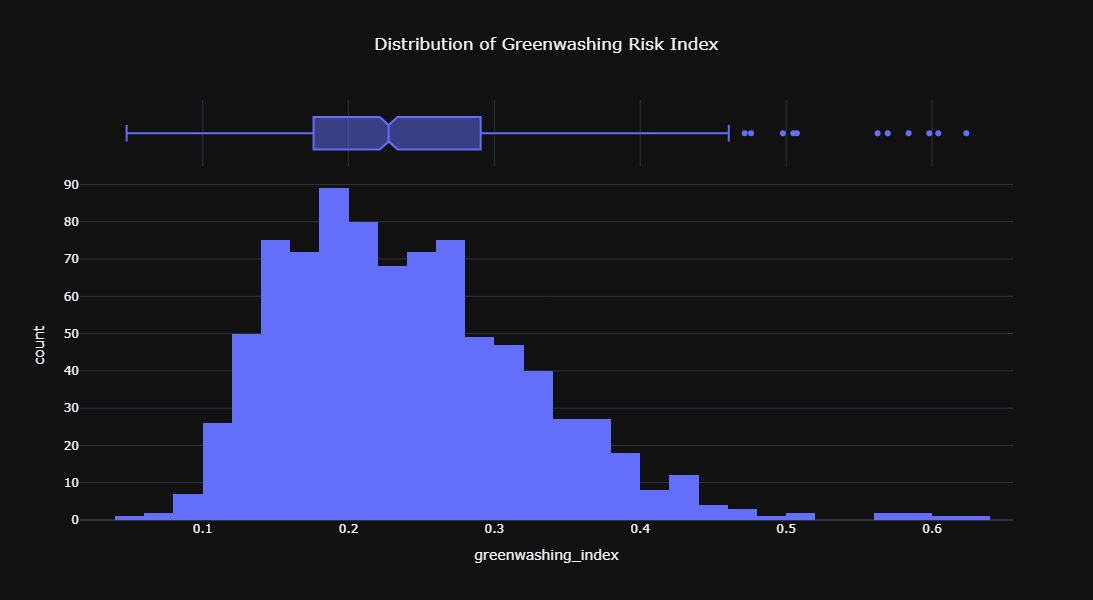

In [70]:
import plotly.express as px

fig = px.histogram(
    merged_df_scaled,
    x="greenwashing_index",
    nbins=30,
    title="Distribution of Greenwashing Risk Index",
    template="plotly_dark",
    marginal="box"
)

fig.update_layout(
    width=1000,
    height=600,
    title_x=0.5
)

fig.show()

In [71]:
merged_df_scaled.to_csv(
    "greenwashing_analysis.csv",
    index=False
)

In [72]:
fig.write_image("RQ4_Top15_Greenwashing_Risk.pdf")

In [73]:
top15 = (
    merged_df_scaled[
        [
            "ticker",
            "greenwashing_index",
            "ESG Risk Level",
            "Sector",
            "Total ESG Risk score"
        ]
    ]
    .sort_values(
        by="greenwashing_index",
        ascending=False
    )
    .head(15)
)

print(top15)

    ticker  greenwashing_index ESG Risk Level              Sector  \
428    COP            0.623561           High              Energy   
632    MMM            0.604357           High         Industrials   
654    NEM            0.598140         Medium     Basic Materials   
631    MMM            0.583991           High         Industrials   
427    COP            0.569659           High              Energy   
653    NEM            0.562721         Medium     Basic Materials   
652    NEM            0.507358         Medium     Basic Materials   
633    MMM            0.504890           High         Industrials   
492    FCX            0.497817           High     Basic Materials   
491    FCX            0.475959           High     Basic Materials   
770    TGT            0.471625            Low  Consumer Defensive   
597    LUV            0.460704           High         Industrials   
665    OXY            0.455907         Severe              Energy   
462    DVN            0.453360    

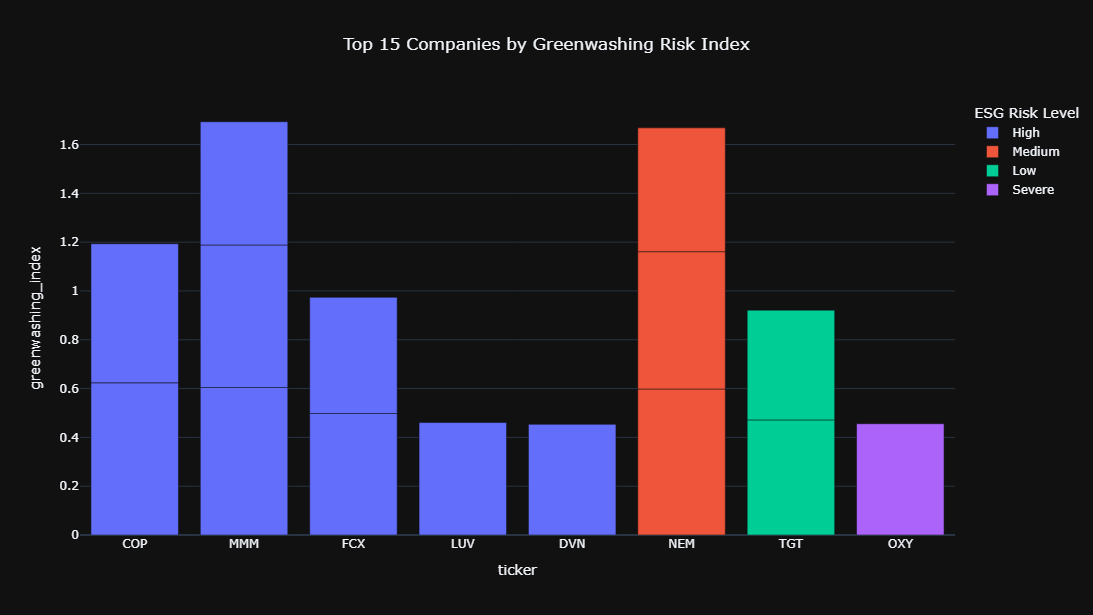

In [74]:
import plotly.express as px

fig = px.bar(
    top15,
    x="ticker",
    y="greenwashing_index",
    color="ESG Risk Level",
    hover_data=[
        "Sector",
        "Total ESG Risk score"
    ],
    title="Top 15 Companies by Greenwashing Risk Index",
    template="plotly_dark"
)

fig.update_layout(
    width=1100,
    height=600,
    title_x=0.5
)

fig.show()

In [75]:
merged_df_scaled["greenwashing_index"].describe()

count    861.000000
mean       0.239627
std        0.086073
min        0.047886
25%        0.176023
50%        0.227512
75%        0.290529
max        0.623561
Name: greenwashing_index, dtype: float64

In [76]:
company_risk = (
    merged_df_scaled
    .groupby("ticker")
    .agg({
        "greenwashing_index": "mean",
        "ESG Risk Level": "first"
    })
    .reset_index()
)

print(company_risk.shape)

(262, 3)


In [77]:
top15 = (
    company_risk
    .sort_values(
        by="greenwashing_index",
        ascending=False
    )
    .head(15)
)

print(top15)

    ticker  greenwashing_index ESG Risk Level
162    MMM            0.564413           High
173    NEM            0.524194         Medium
66     COP            0.498381           High
181    OXY            0.455907         Severe
239    UHS            0.432161           High
24     APA            0.425672           High
227    TGT            0.424268            Low
99     FCX            0.418010           High
185    PCG            0.407555           High
76     CVX            0.403654           High
84     DVN            0.400883           High
257    XOM            0.398905         Severe
89     EIX            0.388212         Medium
91     EOG            0.383149           High
235    TSN            0.368154           High


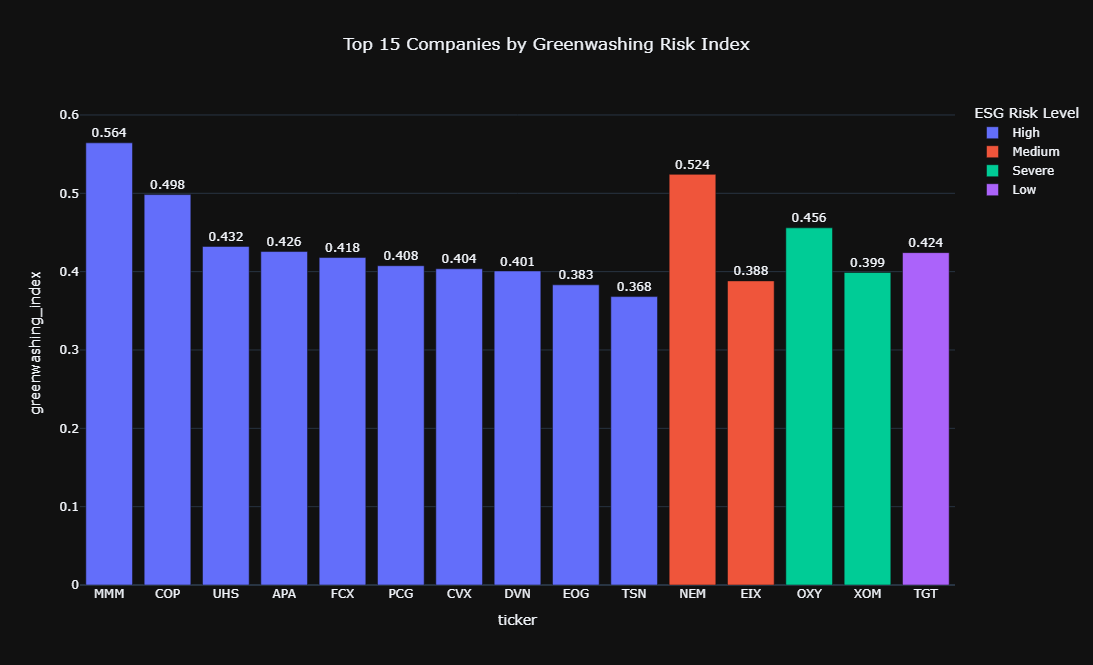

In [78]:
import plotly.express as px

fig = px.bar(
    top15,
    x="ticker",
    y="greenwashing_index",
    color="ESG Risk Level",
    text="greenwashing_index",
    title="Top 15 Companies by Greenwashing Risk Index",
    template="plotly_dark"
)

fig.update_layout(
    width=1200,
    height=650,
    title_x=0.5
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.show()

In [79]:
fig.write_image("RQ4_Top15_Greenwashing_Risk.pdf")

In [80]:
print(top15)

    ticker  greenwashing_index ESG Risk Level
162    MMM            0.564413           High
173    NEM            0.524194         Medium
66     COP            0.498381           High
181    OXY            0.455907         Severe
239    UHS            0.432161           High
24     APA            0.425672           High
227    TGT            0.424268            Low
99     FCX            0.418010           High
185    PCG            0.407555           High
76     CVX            0.403654           High
84     DVN            0.400883           High
257    XOM            0.398905         Severe
89     EIX            0.388212         Medium
91     EOG            0.383149           High
235    TSN            0.368154           High


In [81]:
##RQ5
#Which linguistic and ESG-related features contribute most to Greenwashing Risk predictions?

In [82]:
merged_df_scaled["greenwashing_category"] = pd.cut(
    merged_df_scaled["greenwashing_index"],
    bins=[0, 0.20, 0.35, 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

print(
    merged_df_scaled["greenwashing_category"]
    .value_counts()
)

greenwashing_category
Medium    444
Low       322
High       95
Name: count, dtype: int64


In [83]:
X = merged_df_scaled[
[
    "hedging_count",
    "promotion_count",
    "environmental_density",
    "word_count",
    "Total ESG Risk score"
]
]

y = merged_df_scaled["greenwashing_category"]

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ValueError: Input contains NaN

In [85]:
print(X.isnull().sum())
print("\n")
print(y.isnull().sum())

hedging_count            0
promotion_count          0
environmental_density    0
word_count               0
Total ESG Risk score     1
dtype: int64


1


In [86]:
merged_df_scaled[
[
    "hedging_count",
    "promotion_count",
    "environmental_density",
    "word_count",
    "Total ESG Risk score"
]
].isnull().sum()

hedging_count            0
promotion_count          0
environmental_density    0
word_count               0
Total ESG Risk score     1
dtype: int64

In [87]:
model_df = merged_df_scaled.dropna(
    subset=[
        "hedging_count",
        "promotion_count",
        "environmental_density",
        "word_count",
        "Total ESG Risk score",
        "greenwashing_category"
    ]
)

In [88]:
X = model_df[
[
    "hedging_count",
    "promotion_count",
    "environmental_density",
    "word_count",
    "Total ESG Risk score"
]
]

y = model_df["greenwashing_category"]

In [89]:
print(X.isnull().sum())
print(y.isnull().sum())

hedging_count            0
promotion_count          0
environmental_density    0
word_count               0
Total ESG Risk score     0
dtype: int64
0


In [90]:
print(
    merged_df_scaled["greenwashing_category"]
    .value_counts(dropna=False)
)

greenwashing_category
Medium    444
Low       322
High       95
NaN         1
Name: count, dtype: int64


In [91]:
model_df = merged_df_scaled.dropna(
    subset=[
        "greenwashing_index",
        "greenwashing_category",
        "hedging_count",
        "promotion_count",
        "environmental_density",
        "word_count",
        "Total ESG Risk score"
    ]
)

print(model_df.shape)

(861, 32)


In [92]:
X = model_df[
[
    "hedging_count",
    "promotion_count",
    "environmental_density",
    "word_count",
    "Total ESG Risk score"
]
]

y = model_df["greenwashing_category"]

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [94]:
print(
    merged_df_scaled["greenwashing_category"]
    .value_counts(dropna=False)
)

greenwashing_category
Medium    444
Low       322
High       95
NaN         1
Name: count, dtype: int64


In [95]:
#Fixing to get no NaN

In [96]:
model_df = merged_df_scaled.dropna(
    subset=["greenwashing_category"]
)

print(model_df.shape)

(861, 32)


In [97]:
X = model_df[
[
    "hedging_count",
    "promotion_count",
    "environmental_density",
    "word_count",
    "Total ESG Risk score"
]
]

y = model_df["greenwashing_category"]

In [98]:
print(y.value_counts(dropna=False))

greenwashing_category
Medium    444
Low       322
High       95
Name: count, dtype: int64


In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(688, 5)
(173, 5)


In [100]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [101]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

preds = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Accuracy: 0.9421965317919075

Classification Report:

              precision    recall  f1-score   support

        High       0.94      0.84      0.89        19
         Low       0.93      0.98      0.96        65
      Medium       0.95      0.93      0.94        89

    accuracy                           0.94       173
   macro avg       0.94      0.92      0.93       173
weighted avg       0.94      0.94      0.94       173



In [102]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [103]:
import shap

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

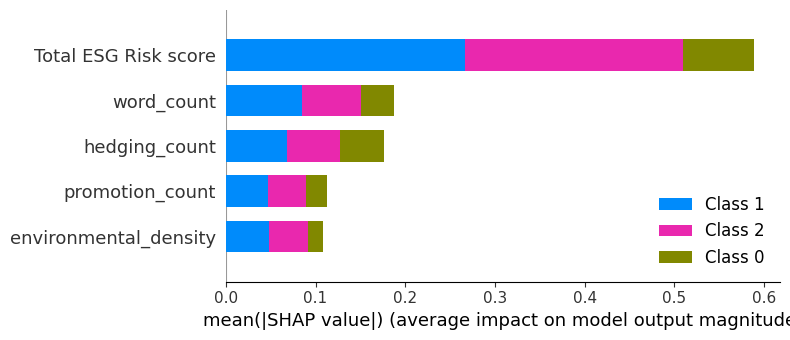

In [104]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [105]:
import pandas as pd
import plotly.express as px

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                 Feature  Importance
4   Total ESG Risk score    0.532715
0          hedging_count    0.144800
3             word_count    0.140111
2  environmental_density    0.092063
1        promotion_count    0.090311


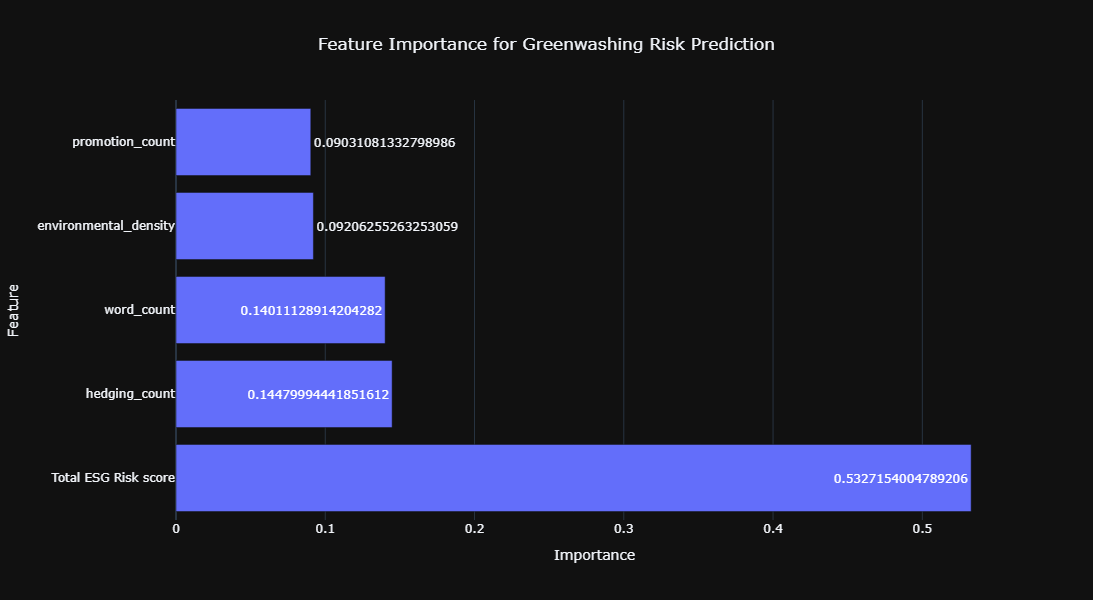

In [106]:
fig = px.bar(
    importance_df,
    x="Importance",
    y="Feature",
    orientation="h",
    title="Feature Importance for Greenwashing Risk Prediction",
    template="plotly_dark",
    text="Importance"
)

fig.update_layout(
    width=1000,
    height=600,
    title_x=0.5
)

fig.show()

In [107]:
fig.write_image("RQ5_Feature_Importance.pdf")